# Step 1: Import Required Liabraries

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
os.getcwd()

'C:\\Users\\HP'

In [4]:
os.chdir('C:\\Users\\HP\\Downloads\\End to End Project\\End to End Project')

# Step 2: Load Dataset

In [5]:
df = pd.read_excel('Ecommerce_Unclean_Project.1.xlsx')

# Step 3: Explore the Dataset

### View First 5 Records

In [6]:
df.head()

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date
0,ORD1002,30-06-2025,Neha,neha82@gmail.com,9.829008e+09,Delhi,Delhi,Chair,Furniture,4.0,1999.0,NaN,UPI,Pending,03-07-2025
1,ORD1003,03-02-2025,Rohit,rohit45@gmail.com,9.280491e+09,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20,Card,Pending,09-02-2025
2,ORD1004,06-05-2025,Amit,amit6@gmail.com,9.943311e+09,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5,COD,Returned,08-05-2025
3,ORD1005,20-01-2025,Vikas,vikas51@gmail.com,9.495120e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,NaN,15,Wallet,Pending,27-01-2025
4,ORD1006,02-04-2025,Rohit,rohit71@gmail.com,9.237332e+09,Pune,Maharashtra,Bottle,Home,NaN,1999.0,,Wallet,Cancelled,07-04-2025


### View Data Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       511 non-null    object 
 1   Order_Date     511 non-null    object 
 2   Customer_Name  511 non-null    object 
 3   Email          511 non-null    object 
 4   Phone          489 non-null    float64
 5   City           511 non-null    object 
 6   State          511 non-null    object 
 7   Product        511 non-null    object 
 8   Category       511 non-null    object 
 9   Qty            446 non-null    float64
 10  Unit_Price     461 non-null    float64
 11  Discount       444 non-null    object 
 12  Payment_Mode   511 non-null    object 
 13  Order_Status   511 non-null    object 
 14  Delivery_Date  491 non-null    object 
dtypes: float64(3), object(12)
memory usage: 60.0+ KB


### Statistical Summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Phone,489.0,9.542441e+09,2.645019e+08,9.104441e+09,9.312273e+09,9.529644e+09,9.792041e+09,9.999074e+09
Qty,446.0,2.802691e+00,1.973212e+00,-1.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,5.000000e+00
Unit_Price,461.0,3.179911e+03,2.974037e+03,4.990000e+02,9.990000e+02,1.999000e+03,4.999000e+03,9.999000e+03


### Dataset Shape

In [9]:
df.shape

(511, 15)

# Step 4: Checking Missing Values

In [10]:
df.isna().sum()

Order_ID          0
Order_Date        0
Customer_Name     0
Email             0
Phone            22
City              0
State             0
Product           0
Category          0
Qty              65
Unit_Price       50
Discount         67
Payment_Mode      0
Order_Status      0
Delivery_Date    20
dtype: int64

# Step 5: Check duplicate Records

In [11]:
df.duplicated().sum()

np.int64(11)

# Remove Duplicate  Records

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

# Step 6: Replace Invalid Values 
#### Replace common invalid values (N/A, NULL,'') with np.nan Jha pr N/A ya NULL ya ''(blank) h isko np.nan yani (blank) se replace kr rhe h, taki hum sari missing values ko ek saath handle kr ske

In [14]:
df.replace(['N/A','NULL',''],np.nan,inplace=True)

In [15]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date
0,ORD1002,30-06-2025,Neha,neha82@gmail.com,9.829008e+09,Delhi,Delhi,Chair,Furniture,4.0,1999.0,NaN,UPI,Pending,03-07-2025
1,ORD1003,03-02-2025,Rohit,rohit45@gmail.com,9.280491e+09,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20,Card,Pending,09-02-2025
2,ORD1004,06-05-2025,Amit,amit6@gmail.com,9.943311e+09,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5,COD,Returned,08-05-2025
3,ORD1005,20-01-2025,Vikas,vikas51@gmail.com,9.495120e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,NaN,15,Wallet,Pending,27-01-2025
4,ORD1006,02-04-2025,Rohit,rohit71@gmail.com,9.237332e+09,Pune,Maharashtra,Bottle,Home,NaN,1999.0,,Wallet,Cancelled,07-04-2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1497,10-06-2025,Rohit,rohit24@gmail.com,9.280006e+09,Lucknow,UP,Shoes,Fashion,NaN,2599.0,15,COD,Returned,16-06-2025
496,ORD1498,26-04-2025,Priya,priya59@gmail.com,9.949871e+09,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10,Wallet,Delivered,03-05-2025
497,ORD1499,09-05-2025,Neha,neha39@gmail.com,9.594172e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,499.0,5,Wallet,Cancelled,11-05-2025
498,ORD1500,15-05-2025,Priya,priya67@gmail.com,9.848201e+09,Pune,Maharashtra,Laptop,Electronics,3.0,NaN,15,UPI,Delivered,NaN


# Step 7: Remove Extra Spaces

In [16]:
df.select_dtypes(include='object').columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Email', 'City', 'State',
       'Product', 'Category', 'Discount', 'Payment_Mode', 'Order_Status',
       'Delivery_Date'],
      dtype='object')

In [17]:
for i in ['Order_ID', 'Order_Date', 'Customer_Name', 'Email', 'City', 'State', 'Product', 'Category', 'Payment_Mode', 'Order_Status', 'Delivery_Date']:
    df[i]=df[i].str.strip()
    

In [18]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date
0,ORD1002,30-06-2025,Neha,neha82@gmail.com,9.829008e+09,Delhi,Delhi,Chair,Furniture,4.0,1999.0,NaN,UPI,Pending,03-07-2025
1,ORD1003,03-02-2025,Rohit,rohit45@gmail.com,9.280491e+09,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20,Card,Pending,09-02-2025
2,ORD1004,06-05-2025,Amit,amit6@gmail.com,9.943311e+09,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5,COD,Returned,08-05-2025
3,ORD1005,20-01-2025,Vikas,vikas51@gmail.com,9.495120e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,NaN,15,Wallet,Pending,27-01-2025
4,ORD1006,02-04-2025,Rohit,rohit71@gmail.com,9.237332e+09,Pune,Maharashtra,Bottle,Home,NaN,1999.0,,Wallet,Cancelled,07-04-2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1497,10-06-2025,Rohit,rohit24@gmail.com,9.280006e+09,Lucknow,UP,Shoes,Fashion,NaN,2599.0,15,COD,Returned,16-06-2025
496,ORD1498,26-04-2025,Priya,priya59@gmail.com,9.949871e+09,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10,Wallet,Delivered,03-05-2025
497,ORD1499,09-05-2025,Neha,neha39@gmail.com,9.594172e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,499.0,5,Wallet,Cancelled,11-05-2025
498,ORD1500,15-05-2025,Priya,priya67@gmail.com,9.848201e+09,Pune,Maharashtra,Laptop,Electronics,3.0,NaN,15,UPI,Delivered,NaN


# Step 8: Standardize Text Format
### Convert Text into Proper Case.

In [19]:
df['Customer_Name']= df.Customer_Name.str.title()
df['City']= df.City.str.title()
df['State']= df.State.str.title()

# Step 9: Validate Email Addresses
### Keep only email records.

In [23]:
df = df[df.Email.str.contains('@', na=False)].copy()

# Step 10: Convert Date Columns (data type)

In [24]:
df['Order_Date'] =pd.to_datetime(df.Order_Date, errors='coerce')   #NaT
df['Delivery_Date'] =pd.to_datetime(df.Delivery_Date, errors='coerce')

In [25]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9.829008e+09,Delhi,Delhi,Chair,Furniture,4.0,1999.0,NaN,UPI,Pending,2025-03-07
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9.280491e+09,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20,Card,Pending,2025-09-02
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9.943311e+09,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5,COD,Returned,2025-08-05
3,ORD1005,2025-01-20,Vikas,vikas51@gmail.com,9.495120e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,NaN,15,Wallet,Pending,NaT
4,ORD1006,2025-04-02,Rohit,rohit71@gmail.com,9.237332e+09,Pune,Maharashtra,Bottle,Home,NaN,1999.0,,Wallet,Cancelled,2025-07-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1497,2025-06-10,Rohit,rohit24@gmail.com,9.280006e+09,Lucknow,Up,Shoes,Fashion,NaN,2599.0,15,COD,Returned,NaT
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9.949871e+09,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10,Wallet,Delivered,2025-03-05
497,ORD1499,2025-05-09,Neha,neha39@gmail.com,9.594172e+09,Bengaluru,Karnataka,Laptop,Electronics,NaN,499.0,5,Wallet,Cancelled,2025-11-05
498,ORD1500,2025-05-15,Priya,priya67@gmail.com,9.848201e+09,Pune,Maharashtra,Laptop,Electronics,3.0,NaN,15,UPI,Delivered,NaT


# Step 11: Convert Numeric Columns

In [26]:
cols= ['Qty','Unit_Price','Discount']

for i in cols:
    df[i]= pd.to_numeric(df[i], errors='coerce')

# Step 12: Remove Invalid Quantity
### Remove Records having negative or Zero Quantity

In [27]:
df = df[df.Qty>0].copy()

In [28]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9.829008e+09,Delhi,Delhi,Chair,Furniture,4.0,1999.0,NaN,UPI,Pending,2025-03-07
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9.280491e+09,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9.943311e+09,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9.517780e+09,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,NaT
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9.789375e+09,Lucknow,Up,Mouse,Electronics,4.0,9999.0,NaN,Card,Returned,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9.961394e+09,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,NaN,COD,Delivered,2025-07-03
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9.703494e+09,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,NaT
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9.580925e+09,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,NaN,NetBanking,Returned,NaT
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9.949871e+09,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05


# Step 13: Filling Missing Values

In [29]:
(df.isna().sum()/len(df))*100

Order_ID          0.000000
Order_Date       12.432432
Customer_Name     0.000000
Email             0.000000
Phone             3.783784
City              0.000000
State             0.000000
Product           0.000000
Category          0.000000
Qty               0.000000
Unit_Price        9.459459
Discount         27.027027
Payment_Mode      0.000000
Order_Status      0.000000
Delivery_Date    64.594595
dtype: float64

In [30]:
df['Discount']= df.Discount.fillna(0)

df['Phone']= df.Phone.astype('object').fillna('Unknown')

df['Delivery_Date'] = df.Delivery_Date.fillna(df.Order_Date)

# Step 14: Feature Engineering
### Create Sales column, Net_Amount column, Profit Column (20% of Net_Amount), Month, Year, Weekday


In [31]:
df['Sales'] = df.Qty * df.Unit_Price

In [32]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,1999.0,0.0,UPI,Pending,2025-03-07,7996.0
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02,24995.0
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05,5997.0
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,2025-02-10,1497.0
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,9999.0,0.0,Card,Returned,2025-02-17,39996.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,0.0,COD,Delivered,2025-07-03,24995.0
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,2025-03-20,4995.0
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,0.0,NetBanking,Returned,NaT,499.0
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05,7495.0


# Net Amount

In [33]:
df['Net_Amount'] = df.Sales - (df.Sales*df.Discount/100)

In [34]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales,Net_Amount
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,1999.0,0.0,UPI,Pending,2025-03-07,7996.0,7996.00
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02,24995.0,19996.00
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05,5997.0,5697.15
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,2025-02-10,1497.0,1197.60
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,9999.0,0.0,Card,Returned,2025-02-17,39996.0,39996.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,0.0,COD,Delivered,2025-07-03,24995.0,24995.00
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,2025-03-20,4995.0,4995.00
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,0.0,NetBanking,Returned,NaT,499.0,499.00
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05,7495.0,6745.50


# Profit (Example: 20%)

In [35]:
df['Profit'] = df['Net_Amount']*.20

In [36]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales,Net_Amount,Profit
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,1999.0,0.0,UPI,Pending,2025-03-07,7996.0,7996.00,1599.20
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02,24995.0,19996.00,3999.20
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05,5997.0,5697.15,1139.43
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,2025-02-10,1497.0,1197.60,239.52
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,9999.0,0.0,Card,Returned,2025-02-17,39996.0,39996.00,7999.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,0.0,COD,Delivered,2025-07-03,24995.0,24995.00,4999.00
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,2025-03-20,4995.0,4995.00,999.00
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,0.0,NetBanking,Returned,NaT,499.0,499.00,99.80
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05,7495.0,6745.50,1349.10


# Order Month

In [37]:
df['Month']= df.Order_Date.dt.month_name()

In [38]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales,Net_Amount,Profit,Month
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,1999.0,0.0,UPI,Pending,2025-03-07,7996.0,7996.00,1599.20,June
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02,24995.0,19996.00,3999.20,February
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05,5997.0,5697.15,1139.43,May
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,2025-02-10,1497.0,1197.60,239.52,February
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,9999.0,0.0,Card,Returned,2025-02-17,39996.0,39996.00,7999.20,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,0.0,COD,Delivered,2025-07-03,24995.0,24995.00,4999.00,March
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,2025-03-20,4995.0,4995.00,999.00,March
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,0.0,NetBanking,Returned,NaT,499.0,499.00,99.80,NaN
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05,7495.0,6745.50,1349.10,April


# Order Year

In [39]:
df['Year'] = df.Order_Date.dt.year

In [40]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,Unit_Price,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales,Net_Amount,Profit,Month,Year
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,1999.0,0.0,UPI,Pending,2025-03-07,7996.0,7996.00,1599.20,June,2025.0
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,4999.0,20.0,Card,Pending,2025-09-02,24995.0,19996.00,3999.20,February,2025.0
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,1999.0,5.0,COD,Returned,2025-08-05,5997.0,5697.15,1139.43,May,2025.0
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,499.0,20.0,Wallet,Cancelled,2025-02-10,1497.0,1197.60,239.52,February,2025.0
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,9999.0,0.0,Card,Returned,2025-02-17,39996.0,39996.00,7999.20,February,2025.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,4999.0,0.0,COD,Delivered,2025-07-03,24995.0,24995.00,4999.00,March,2025.0
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,999.0,0.0,Wallet,Delivered,2025-03-20,4995.0,4995.00,999.00,March,2025.0
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,499.0,0.0,NetBanking,Returned,NaT,499.0,499.00,99.80,NaN,NaN
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,1499.0,10.0,Wallet,Delivered,2025-03-05,7495.0,6745.50,1349.10,April,2025.0


# WeekDay

In [41]:
df['Weekday'] = df.Order_Date.dt.day_name()

In [42]:
df

,Order_ID,Order_Date,Customer_Name,Email,Phone,City,State,Product,Category,Qty,...,Discount,Payment_Mode,Order_Status,Delivery_Date,Sales,Net_Amount,Profit,Month,Year,Weekday
0,ORD1002,2025-06-30,Neha,neha82@gmail.com,9829008196.0,Delhi,Delhi,Chair,Furniture,4.0,...,0.0,UPI,Pending,2025-03-07,7996.0,7996.00,1599.20,June,2025.0,Monday
1,ORD1003,2025-02-03,Rohit,rohit45@gmail.com,9280491167.0,Pune,Maharashtra,Watch,Fashion,5.0,...,20.0,Card,Pending,2025-09-02,24995.0,19996.00,3999.20,February,2025.0,Monday
2,ORD1004,2025-05-06,Amit,amit6@gmail.com,9943310925.0,Jaipur,Rajasthan,Mouse,Electronics,3.0,...,5.0,COD,Returned,2025-08-05,5997.0,5697.15,1139.43,May,2025.0,Tuesday
5,ORD1007,2025-02-10,Rahul,rahul82@gmail.com,9517780193.0,Mumbai,Maharashtra,Mouse,Electronics,3.0,...,20.0,Wallet,Cancelled,2025-02-10,1497.0,1197.60,239.52,February,2025.0,Monday
6,ORD1008,2025-02-17,Rahul,rahul71@gmail.com,9789375429.0,Lucknow,Up,Mouse,Electronics,4.0,...,0.0,Card,Returned,2025-02-17,39996.0,39996.00,7999.20,February,2025.0,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,ORD1493,2025-03-05,Sneha,sneha27@gmail.com,9961393609.0,Delhi,Delhi,Mouse,Electronics,5.0,...,0.0,COD,Delivered,2025-07-03,24995.0,24995.00,4999.00,March,2025.0,Wednesday
492,ORD1494,2025-03-20,Sneha,sneha50@gmail.com,9703494194.0,Delhi,Delhi,Bottle,Home,5.0,...,0.0,Wallet,Delivered,2025-03-20,4995.0,4995.00,999.00,March,2025.0,Thursday
493,ORD1495,NaT,Sneha,sneha59@gmail.com,9580925306.0,Bengaluru,Karnataka,Mouse,Electronics,1.0,...,0.0,NetBanking,Returned,NaT,499.0,499.00,99.80,NaN,NaN,NaN
496,ORD1498,2025-04-26,Priya,priya59@gmail.com,9949870677.0,Jaipur,Rajasthan,Mouse,Electronics,5.0,...,10.0,Wallet,Delivered,2025-03-05,7495.0,6745.50,1349.10,April,2025.0,Saturday


# Outlier Detection

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

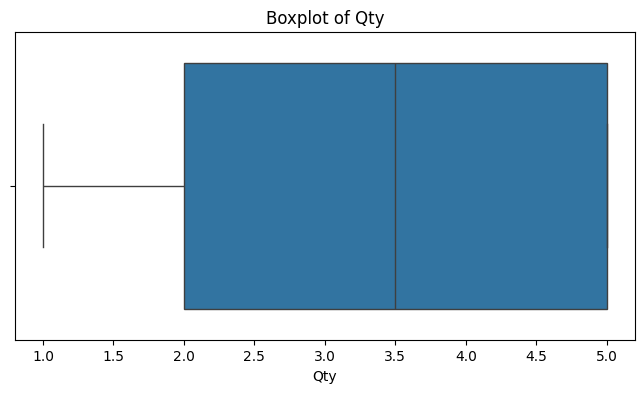

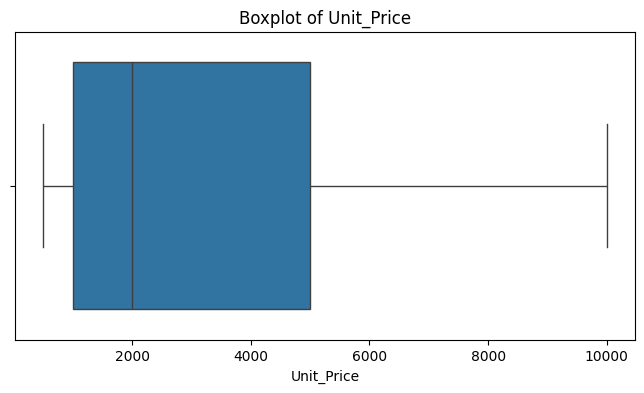

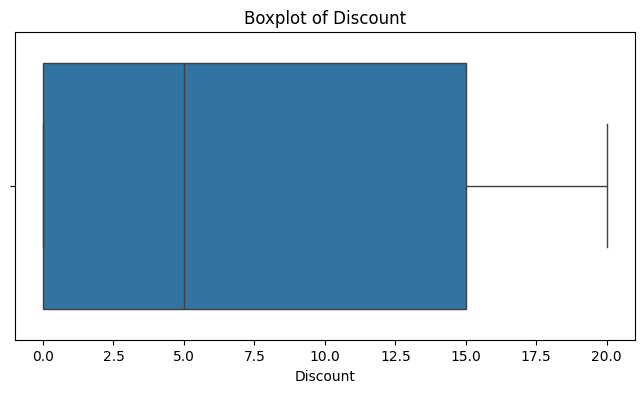

In [44]:
num_columns=['Qty','Unit_Price','Discount']

for i in num_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()
    

In [45]:
# Step: Outlier Detection using IQR

num_cols = ['Qty', 'Unit_Price', 'Discount']

for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[i] < lower) | 
        (df[i] > upper)
    ]

    print(f"{i}: {len(outliers)} outliers")

Qty: 0 outliers
Unit_Price: 0 outliers
Discount: 0 outliers


# Step 15: Final Data Validation

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370 entries, 0 to 498
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       370 non-null    object        
 1   Order_Date     324 non-null    datetime64[ns]
 2   Customer_Name  370 non-null    object        
 3   Email          370 non-null    object        
 4   Phone          370 non-null    object        
 5   City           370 non-null    object        
 6   State          370 non-null    object        
 7   Product        370 non-null    object        
 8   Category       370 non-null    object        
 9   Qty            370 non-null    float64       
 10  Unit_Price     335 non-null    float64       
 11  Discount       370 non-null    float64       
 12  Payment_Mode   370 non-null    object        
 13  Order_Status   370 non-null    object        
 14  Delivery_Date  339 non-null    datetime64[ns]
 15  Sales          335 non-null 

In [47]:
df.isna().sum()

Order_ID          0
Order_Date       46
Customer_Name     0
Email             0
Phone             0
City              0
State             0
Product           0
Category          0
Qty               0
Unit_Price       35
Discount          0
Payment_Mode      0
Order_Status      0
Delivery_Date    31
Sales            35
Net_Amount       35
Profit           35
Month            46
Year             46
Weekday          46
dtype: int64

In [48]:
df.describe()

,Order_Date,Qty,Unit_Price,Discount,Delivery_Date,Sales,Net_Amount,Profit,Year
count,324,370.000000,335.000000,370.000000,339,335.000000,335.000000,335.000000,324.0
mean,2025-04-03 00:44:26.666666752,3.335135,3261.388060,7.837838,2025-05-01 02:54:09.557522176,11101.743284,10243.902239,2048.780448,2025.0
min,2025-01-01 00:00:00,1.000000,499.000000,0.000000,2025-01-02 00:00:00,499.000000,399.200000,79.840000,2025.0
25%,2025-02-14 00:00:00,2.000000,999.000000,0.000000,2025-02-16 12:00:00,2599.000000,2398.000000,479.600000,2025.0
50%,2025-04-05 00:00:00,3.500000,1999.000000,5.000000,2025-04-19 00:00:00,5997.000000,5996.000000,1199.200000,2025.0
75%,2025-05-17 00:00:00,5.000000,4999.000000,15.000000,2025-06-17 12:00:00,12995.000000,12995.000000,2599.000000,2025.0
max,2025-06-30 00:00:00,5.000000,9999.000000,20.000000,2025-12-06 00:00:00,49995.000000,49995.000000,9999.000000,2025.0
std,NaN,1.467298,3026.443383,7.872678,NaN,12174.471750,11481.626653,2296.325331,0.0


### Validation Summary

The dataset contains 370 rows and 21 columns.

Missing values were identified in some columns during the final validation.

The missing values were not removed from the dataset at this stage because removing those records could result in loss of useful data.

The required missing-value handling was performed in Power BI during the reporting stage.

Therefore, Python was used for data cleaning, transformation and validation, while Power BI was used for final reporting and dashboard-level handling of missing values.

# Step 16: Export Clean Data

The cleaned and validated dataset was exported to CSV format for further analysis and reporting.

The exported file was used for the SQL Server and Power BI analysis.

In [205]:
df.to_csv('Clean_Ecommerce.csv', index=False)a

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370 entries, 0 to 498
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       370 non-null    object        
 1   Order_Date     324 non-null    datetime64[ns]
 2   Customer_Name  370 non-null    object        
 3   Email          370 non-null    object        
 4   Phone          370 non-null    object        
 5   City           370 non-null    object        
 6   State          370 non-null    object        
 7   Product        370 non-null    object        
 8   Category       370 non-null    object        
 9   Qty            370 non-null    float64       
 10  Unit_Price     335 non-null    float64       
 11  Discount       370 non-null    float64       
 12  Payment_Mode   370 non-null    object        
 13  Order_Status   370 non-null    object        
 14  Delivery_Date  339 non-null    datetime64[ns]
 15  Sales          335 non-null 

In [209]:
df.shape

(370, 21)